## Imports

In [1]:
import os
from pathlib import Path
import pandas as pd

## Define paths

In [2]:
# Make project root importable
ROOT_DIR = os.path.abspath(os.path.join(".."))
if ROOT_DIR not in sys.path:
    sys.path.append(ROOT_DIR)

CBIS_ROOT = os.path.join(
    ROOT_DIR,
    "data",
    "raw",
    "CBIS-DDSM-All-doiJNLP-zzWs5zfZ"
)

METADATA_FILE = os.path.join(
    CBIS_ROOT,
    "metadata",
    "metadata.csv"
)

MASS_TRAIN_FILE = os.path.join(
    ROOT_DIR,
    "data",
    "raw",
    "mass_case_description_train_set.csv"
)

IMAGE_ROOT = os.path.join(
    CBIS_ROOT,
    "cbis_ddsm"
)

SAVE_ROOT = os.path.join(
    CBIS_ROOT,
    "metadata"
)

## Load data

In [3]:
meta = pd.read_csv(METADATA_FILE)

mass = pd.read_csv(MASS_TRAIN_FILE)

print("Metadata rows:", len(meta))
print("Mass rows:", len(mass))

Metadata rows: 6775
Mass rows: 1318


## Parse TCIA PatientIDs

### Example:
Mass-Training_P_00849_LEFT_MLO_1

Mass-Training_P_01776_RIGHT_CC

P_01004_LEFT_MLO_1.dcm

### into:

patient_id = P_00849

side       = LEFT

view       = MLO


In [4]:
def parse_tcia_patientid(pid):

    pid = str(pid).replace(".dcm", "")

    parts = pid.split("_")

    p_index = None

    for i, token in enumerate(parts):
        if token == "P":
            p_index = i
            break

    if p_index is None:
        return pd.Series([None, None, None])

    patient_id = f"P_{parts[p_index + 1]}"

    side = None
    view = None

    for token in parts:

        if token in ["LEFT", "RIGHT"]:
            side = token

        if token in ["CC", "MLO"]:
            view = token

    return pd.Series([patient_id, side, view])

## Build lookup table

In [5]:
meta[["patient_id", "side", "view"]] = (
    meta["PatientID"]
    .apply(parse_tcia_patientid)
)

meta.head()

,PatientID,StudyInstanceUID,SeriesInstanceUID,Collection,FileSize,DownloadURL,S5cmdManifestPath,OriginalS5cmdURI,completion_status,patient_id,side,view
0,P_01004_LEFT_MLO_1.dcm,1.3.6.1.4.1.9590.100.1.2.265198230512455509519...,1.3.6.1.4.1.9590.100.1.2.294445047912407030012...,cbis_ddsm,23645061,s3://idc-open-data/b4dd3465-76ef-4cb3-baa8-f91...,/Users/gibionmakiwa/MyDocuments/610MtSundanceB...,s3://idc-open-data/b4dd3465-76ef-4cb3-baa8-f91...,success,P_01004,LEFT,MLO
1,P_00038_LEFT_MLO_1.dcm,1.3.6.1.4.1.9590.100.1.2.291121996131431385353...,1.3.6.1.4.1.9590.100.1.2.188613955710170417803...,cbis_ddsm,14620630,s3://idc-open-data/620b14e7-eeb0-4570-869a-310...,/Users/gibionmakiwa/MyDocuments/610MtSundanceB...,s3://idc-open-data/620b14e7-eeb0-4570-869a-310...,success,P_00038,LEFT,MLO
2,Calc-Test_P_00041_LEFT_MLO_2,1.3.6.1.4.1.9590.100.1.2.372962290011068589008...,1.3.6.1.4.1.9590.100.1.2.399466258212646932018...,cbis_ddsm,22926678,s3://idc-open-data/a6922d61-0a1c-4b07-9abf-f88...,/Users/gibionmakiwa/MyDocuments/610MtSundanceB...,s3://idc-open-data/a6922d61-0a1c-4b07-9abf-f88...,success,P_00041,LEFT,MLO
3,Calc-Test_P_00038_LEFT_CC_1,1.3.6.1.4.1.9590.100.1.2.161465562211359959230...,1.3.6.1.4.1.9590.100.1.2.419081637812053404913...,cbis_ddsm,14055890,s3://idc-open-data/77040702-ff2e-49bf-86ec-933...,/Users/gibionmakiwa/MyDocuments/610MtSundanceB...,s3://idc-open-data/77040702-ff2e-49bf-86ec-933...,success,P_00038,LEFT,CC
4,P_00485_LEFT_CC_3.dcm,1.3.6.1.4.1.9590.100.1.2.188175119112669404616...,1.3.6.1.4.1.9590.100.1.2.284547955212024760928...,cbis_ddsm,24814482,s3://idc-open-data/5675e752-f3a9-43ce-ac49-273...,/Users/gibionmakiwa/MyDocuments/610MtSundanceB...,s3://idc-open-data/5675e752-f3a9-43ce-ac49-273...,success,P_00485,LEFT,CC


## Verify parsing worked

In [6]:
meta[
    ["PatientID", "patient_id", "side", "view"]
].head(20)

,PatientID,patient_id,side,view
0,P_01004_LEFT_MLO_1.dcm,P_01004,LEFT,MLO
1,P_00038_LEFT_MLO_1.dcm,P_00038,LEFT,MLO
2,Calc-Test_P_00041_LEFT_MLO_2,P_00041,LEFT,MLO
3,Calc-Test_P_00038_LEFT_CC_1,P_00038,LEFT,CC
4,P_00485_LEFT_CC_3.dcm,P_00485,LEFT,CC
5,P_01399_RIGHT_CC.dcm,P_01399,RIGHT,CC
6,Mass-Training_P_00074_RIGHT_MLO_1,P_00074,RIGHT,MLO
7,Calc-Training_P_00750_RIGHT_MLO_2,P_00750,RIGHT,MLO
8,Mass-Training_P_01776_RIGHT_CC,P_01776,RIGHT,CC
9,Mass-Training_P_00841_RIGHT_CC_1,P_00841,RIGHT,CC


## Build matching dictionary

In [7]:
lookup = {}

for _, row in meta.iterrows():

    key = (
        row["patient_id"],
        row["side"],
        row["view"]
    )

    lookup.setdefault(key, []).append(
        row["PatientID"]
    )

print("Unique keys:", len(lookup))

Unique keys: 3032


## Locate DICOM files

In [8]:
IMAGE_ROOT = Path(IMAGE_ROOT)

def find_dicom(patient_folder):

    folder = IMAGE_ROOT / patient_folder

    if not folder.exists():
        return None

    files = list(folder.rglob("*.dcm"))

    if len(files) == 0:
        return None

    return str(files[0])

## Test on one example

In [9]:
row = mass.iloc[0]

key = (
    row["patient_id"],
    row["left or right breast"],
    row["image view"]
)

print(key)

lookup.get(key, [])

('P_00001', 'LEFT', 'CC')


['Mass-Training_P_00001_LEFT_CC_1', 'Mass-Training_P_00001_LEFT_CC']

## Map all mass records to TCIA folders

In [10]:
def get_patient_folder(row):

    key = (
        row["patient_id"],
        row["left or right breast"],
        row["image view"]
    )

    matches = lookup.get(key)

    if not matches:
        return None

    return matches[0]

In [11]:
mass["tcia_folder"] = mass.apply(
    get_patient_folder,
    axis=1
)

## Find actual DICOM files

In [12]:
mass["actual_dicom_path"] = (
    mass["tcia_folder"]
    .apply(
        lambda x: find_dicom(x)
        if pd.notna(x)
        else None
    )
)

## Check results

In [13]:
mass[
    [
        "patient_id",
        "left or right breast",
        "image view",
        "tcia_folder",
        "actual_dicom_path"
    ]
].head(20)

,patient_id,left or right breast,image view,tcia_folder,actual_dicom_path
0,P_00001,LEFT,CC,Mass-Training_P_00001_LEFT_CC_1,/Users/gibionmakiwa/MyDocuments/610MtSundanceB...
1,P_00001,LEFT,MLO,Mass-Training_P_00001_LEFT_MLO,/Users/gibionmakiwa/MyDocuments/610MtSundanceB...
2,P_00004,LEFT,CC,Mass-Training_P_00004_LEFT_CC_1,/Users/gibionmakiwa/MyDocuments/610MtSundanceB...
3,P_00004,LEFT,MLO,Mass-Training_P_00004_LEFT_MLO,/Users/gibionmakiwa/MyDocuments/610MtSundanceB...
4,P_00004,RIGHT,MLO,Mass-Training_P_00004_RIGHT_MLO_1,/Users/gibionmakiwa/MyDocuments/610MtSundanceB...
5,P_00009,RIGHT,CC,Mass-Training_P_00009_RIGHT_CC_1,/Users/gibionmakiwa/MyDocuments/610MtSundanceB...
6,P_00009,RIGHT,MLO,Mass-Training_P_00009_RIGHT_MLO_1,/Users/gibionmakiwa/MyDocuments/610MtSundanceB...
7,P_00015,LEFT,MLO,Mass-Training_P_00015_LEFT_MLO,/Users/gibionmakiwa/MyDocuments/610MtSundanceB...
8,P_00018,RIGHT,CC,Mass-Training_P_00018_RIGHT_CC,/Users/gibionmakiwa/MyDocuments/610MtSundanceB...
9,P_00018,RIGHT,MLO,Mass-Training_P_00018_RIGHT_MLO,/Users/gibionmakiwa/MyDocuments/610MtSundanceB...


## Load and display an image

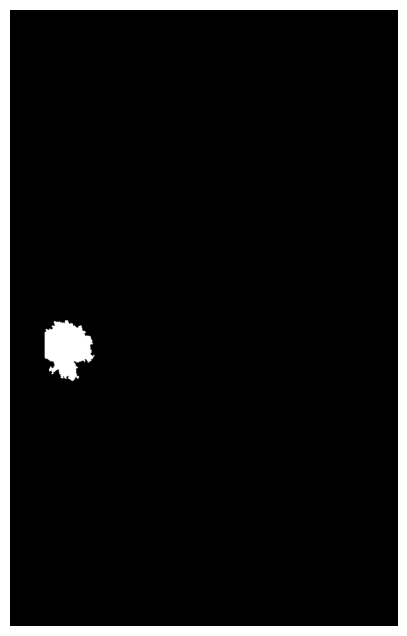

In [14]:
import pydicom
import matplotlib.pyplot as plt

path = mass.loc[0, "actual_dicom_path"]

ds = pydicom.dcmread(path)

img = ds.pixel_array

plt.figure(figsize=(8, 8))
plt.imshow(img, cmap="gray")
plt.axis("off")
plt.show()

## Save the mapping

In [15]:
mass.to_csv(SAVE_ROOT + 
    "/mass_train_with_dicom_paths.csv",
    index=False
)

print("Saved successfully")

Saved successfully


In [16]:
pwd

'/Users/gibionmakiwa/MyDocuments/610MtSundanceBayW/University_of_London_Computer_Science_BSc/CM3070 Computer Science Final Project/multimodal-mammography-xai/notebooks'

In [1]:
!pip install pandoc

In [2]:
reset

Once deleted, variables cannot be recovered. Proceed (y/[n])?  y
